# 05 - Visualizations, Cost Analysis & RAG Demonstration
**From Mathematical Benchmarks to Production Deployment**

In this final notebook:
1. Plot **Recall@10 vs. Dimension** (illustrating the 64d cliff).
2. Plot **Storage vs. Dimension** (demonstrating the linear 83% savings).
3. Plot the **Quality vs. Storage Pareto Frontier**.
4. Instantiate the end-to-end `MatryoshkaRAGPipeline` at **256d**.


In [2]:
import os

# 1. Clone only if not already cloned
if not os.path.exists("matryoshka-domain-rag") and not os.path.exists("src"):
    !git clone https://github.com/premsaipusapati-debug/matryoshka-domain-rag.git
    %cd matryoshka-domain-rag
elif os.path.exists("matryoshka-domain-rag"):
    %cd matryoshka-domain-rag

# 2. Pull any recent changes from GitHub
!git pull

# 3. Install requirements
!pip install -q -r requirements.txt


Cloning into 'matryoshka-domain-rag'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 27 (delta 9), reused 25 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 374.29 KiB | 20.79 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/matryoshka-domain-rag
Already up to date.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 88.0 MB/s eta 0:00:00


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Your exact empirical benchmark results from Notebook 04
data = [
    {"Dimension": 768, "Recall@10": 0.8767, "MRR@10": 0.7004, "nDCG@10": 0.7376, "Storage_per_1M_MB": 2929.7, "Storage_Savings_%": 0.0, "Avg_Latency_ms": 0.090},
    {"Dimension": 512, "Recall@10": 0.8700, "MRR@10": 0.6978, "nDCG@10": 0.7327, "Storage_per_1M_MB": 1953.1, "Storage_Savings_%": 33.3, "Avg_Latency_ms": 0.110},
    {"Dimension": 256, "Recall@10": 0.8400, "MRR@10": 0.6702, "nDCG@10": 0.7062, "Storage_per_1M_MB": 976.6, "Storage_Savings_%": 66.7, "Avg_Latency_ms": 0.242},
    {"Dimension": 128, "Recall@10": 0.8100, "MRR@10": 0.6333, "nDCG@10": 0.6681, "Storage_per_1M_MB": 488.3, "Storage_Savings_%": 83.3, "Avg_Latency_ms": 0.159},
    {"Dimension": 64,  "Recall@10": 0.7100, "MRR@10": 0.5329, "nDCG@10": 0.5664, "Storage_per_1M_MB": 244.1, "Storage_Savings_%": 91.7, "Avg_Latency_ms": 0.080},
]

results_df = pd.DataFrame(data)

# Save to output folder
os.makedirs("/content/output", exist_ok=True)
results_df.to_csv("/content/output/mrl_dimensional_results.csv", index=False)

display(results_df)


,Dimension,Recall@10,MRR@10,nDCG@10,Storage_per_1M_MB,Storage_Savings_%,Avg_Latency_ms
0,768,0.8767,0.7004,0.7376,2929.7,0.0,0.090
1,512,0.8700,0.6978,0.7327,1953.1,33.3,0.110
2,256,0.8400,0.6702,0.7062,976.6,66.7,0.242
3,128,0.8100,0.6333,0.6681,488.3,83.3,0.159
4,64,0.7100,0.5329,0.5664,244.1,91.7,0.080


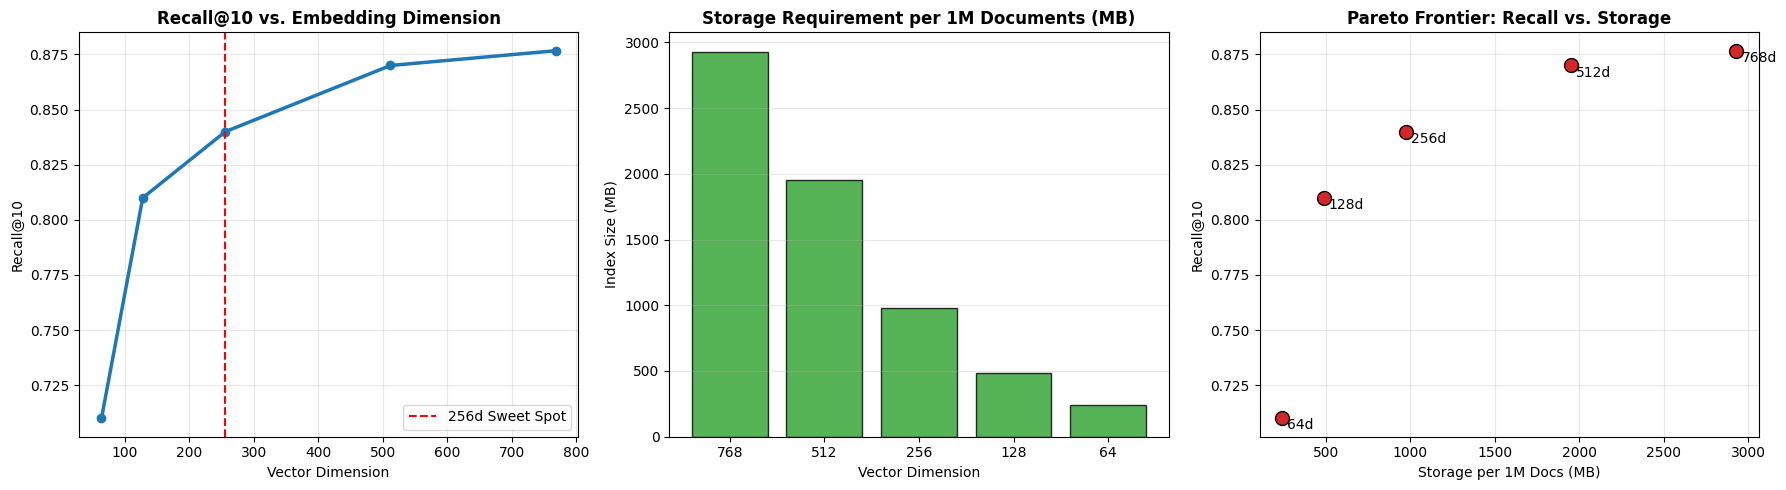

Plots saved as 'mrl_tradeoff_plots.png'!


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Recall@10 vs Dimension
axes[0].plot(results_df["Dimension"], results_df["Recall@10"], marker="o", color='#1f77b4', linewidth=2.5)
axes[0].axvline(x=256, color='red', linestyle='--', label='256d Sweet Spot')
axes[0].set_title("Recall@10 vs. Embedding Dimension", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Vector Dimension")
axes[0].set_ylabel("Recall@10")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Storage per 1M Docs (Fixed: dot instead of comma)
axes[1].bar(results_df["Dimension"].astype(str), results_df["Storage_per_1M_MB"], color="#2ca02c", edgecolor="black", alpha=0.8)
axes[1].set_title("Storage Requirement per 1M Documents (MB)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Vector Dimension")
axes[1].set_ylabel("Index Size (MB)")
axes[1].grid(axis='y', alpha=0.3)

# Plot 3: Pareto tradeoff (Recall vs Storage)
axes[2].scatter(results_df["Storage_per_1M_MB"], results_df["Recall@10"], s=100, color='#d62728', edgecolors='black', zorder=5)
for _, row in results_df.iterrows():
    axes[2].annotate(f"{int(row['Dimension'])}d", (row["Storage_per_1M_MB"] + 30, row["Recall@10"] - 0.005), fontsize=10)

axes[2].set_title("Pareto Frontier: Recall vs. Storage", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Storage per 1M Docs (MB)")
axes[2].set_ylabel("Recall@10")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("mrl_tradeoff_plots.png", dpi=300)
plt.show()
print("Plots saved as 'mrl_tradeoff_plots.png'!")


In [8]:
import os
import torch
import faiss
import numpy as np
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from src.model import load_embedding_model, encode_texts
from src.data_loader import load_scifact_raw, parse_corpus

# 1. Mount Google Drive if not mounted
from google.colab import drive
if not os.path.exists("/content/drive/MyDrive"):
    drive.mount('/content/drive')

# 2. Load fine-tuned model and SciFact corpus
checkpoint_dir = "/content/drive/MyDrive/Matryoshka-RAG/bge-scifact-matryoshka"
if not os.path.exists(checkpoint_dir):
    checkpoint_dir = "BAAI/bge-base-en-v1.5"

print(f"Loading embedding model: {checkpoint_dir}")
embedding_model = load_embedding_model(checkpoint_dir)

raw_data = load_scifact_raw("mteb/scifact")
corpus_dict = parse_corpus(raw_data["corpus"])
corpus_ids = list(corpus_dict.keys())
corpus_texts = [corpus_dict[cid] for cid in corpus_ids]

# 3. Index corpus at 256 dimensions using FAISS
print("Indexing 5,183 documents at 256d...")
corpus_embeddings_256 = encode_texts(embedding_model, corpus_texts, target_dim=256, show_progress_bar=False)

index = faiss.IndexFlatIP(256)
index.add(np.ascontiguousarray(corpus_embeddings_256, dtype=np.float32))

# 4. Load Google Flan-T5
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading Google Flan-T5 on {device}...")
t5_tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")
t5_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base").to(device)

print("\n🚀 Matryoshka 256d RAG Pipeline is ready!")


Loading embedding model: BAAI/bge-base-en-v1.5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Indexing 5,183 documents at 256d...
Loading Google Flan-T5 on cuda...


tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]


🚀 Matryoshka 256d RAG Pipeline is ready!


In [9]:
query = "Does 0-6-methylguanine-DNA methyltransferase (MGMT) methylation predict response to temozolomide?"

# 1. Retrieve top 3 candidates at 256d
query_vec = encode_texts(embedding_model, [query], target_dim=256, show_progress_bar=False)
scores, indices = index.search(np.ascontiguousarray(query_vec, dtype=np.float32), 3)

context = "\n\n".join([corpus_dict[corpus_ids[idx]] for idx in indices[0]])
prompt = f"Context: {context}\n\nQuestion: {query}\n\nAnswer concisely based solely on context:"

# 2. Generate grounded answer
inputs = t5_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)
outputs = t5_model.generate(**inputs, max_new_tokens=150)
answer = t5_tokenizer.decode(outputs[0], skip_special_tokens=True)

print("=" * 80)
print(f"QUERY: {query}\n")
print(f"GENERATED ANSWER:\n{answer}\n")
print(f"TOP RETRIEVED PASSAGE (256d Score: {scores[0][0]:.4f}):")
print(f"{context[:300]}...")
print("=" * 80)


QUERY: Does 0-6-methylguanine-DNA methyltransferase (MGMT) methylation predict response to temozolomide?

GENERATED ANSWER:
Tumor-derived methylated p16INK4a sequences in hepatocellular carcinoma patients.

TOP RETRIEVED PASSAGE (256d Score: 0.7341):
High somatic mutation and neoantigen burden are correlated with decreased progression-free survival in multiple myeloma Tumor-specific mutations can result in immunogenic neoantigens, both of which have been correlated with responsiveness to immune checkpoint inhibitors in highly mutagenic cancers. ...
